In [ ]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering



In [ ]:
# Load Dataset
df = pd.read_excel("World_development_mesurement.xlsx")


In [ ]:
df.head()


,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"


In [ ]:
# Shape of data
df.shape

(2704, 25)

In [ ]:
# Column names
df.columns

Index(['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Country',
       'Days to Start Business', 'Ease of Business', 'Energy Usage', 'GDP',
       'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax',
       'Infant Mortality Rate', 'Internet Usage', 'Lending Interest',
       'Life Expectancy Female', 'Life Expectancy Male', 'Mobile Phone Usage',
       'Number of Records', 'Population 0-14', 'Population 15-64',
       'Population 65+', 'Population Total', 'Population Urban',
       'Tourism Inbound', 'Tourism Outbound'],
      dtype='object')

In [ ]:
# Data types
df.dtypes


,0
Birth Rate,float64
Business Tax Rate,object
CO2 Emissions,float64
Country,object
Days to Start Business,float64
Ease of Business,float64
Energy Usage,float64
GDP,object
Health Exp % GDP,float64
Health Exp/Capita,object


In [ ]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2704 entries, 0 to 2703
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Birth Rate              2585 non-null   float64
 1   Business Tax Rate       1423 non-null   object 
 2   CO2 Emissions           2125 non-null   float64
 3   Country                 2704 non-null   object 
 4   Days to Start Business  1718 non-null   float64
 5   Ease of Business        185 non-null    float64
 6   Energy Usage            1785 non-null   float64
 7   GDP                     2494 non-null   object 
 8   Health Exp % GDP        2395 non-null   float64
 9   Health Exp/Capita       2395 non-null   object 
 10  Hours to do Tax         1416 non-null   float64
 11  Infant Mortality Rate   2444 non-null   float64
 12  Internet Usage          2531 non-null   float64
 13  Lending Interest        1880 non-null   float64
 14  Life Expectancy Female  2568 non-null   

In [ ]:
# Statistical Summary
df.describe()

,Birth Rate,CO2 Emissions,Days to Start Business,Ease of Business,Energy Usage,Health Exp % GDP,Hours to do Tax,Infant Mortality Rate,Internet Usage,Lending Interest,Life Expectancy Female,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban
count,2585.000000,2.125000e+03,1718.000000,185.000000,1.785000e+03,2395.000000,1416.000000,2444.000000,2531.000000,1880.000000,2568.000000,2568.000000,2537.000000,2704.0,2484.000000,2484.000000,2484.000000,2.704000e+03,2678.000000
mean,0.022715,1.423071e+05,39.999418,94.875676,7.723684e+04,0.064170,302.068503,0.032813,0.239747,0.148103,71.159268,66.461838,0.578124,1.0,0.303051,0.623481,0.073465,3.145729e+07,0.562953
std,0.011338,6.159288e+05,57.318588,54.791906,2.599239e+05,0.026325,273.299686,0.029968,0.260132,0.171829,10.708262,9.390217,0.474647,0.0,0.106577,0.069660,0.049541,1.242894e+08,0.245897
min,0.007000,7.000000e+00,1.000000,1.000000,8.000000e+00,0.008000,12.000000,0.002000,0.000000,0.005000,39.000000,37.000000,0.000000,1.0,0.118000,0.474000,0.003000,1.887600e+04,0.082000
25%,0.013000,1.360000e+03,13.000000,48.000000,3.737000e+03,0.046000,156.000000,0.009000,0.000000,0.080000,64.000000,61.000000,0.100000,1.0,0.204750,0.559000,0.033000,8.783360e+05,0.356000
50%,0.020000,8.529000e+03,26.000000,94.000000,1.433800e+04,0.061000,239.000000,0.020000,0.100000,0.120000,75.000000,69.000000,0.500000,1.0,0.299500,0.642500,0.052000,5.800324e+06,0.560000
75%,0.031000,5.910800e+04,45.000000,142.000000,4.185200e+04,0.079000,344.750000,0.053000,0.400000,0.173000,79.000000,73.250000,0.900000,1.0,0.402000,0.676000,0.112000,2.014089e+07,0.765000
max,0.053000,8.286892e+06,694.000000,189.000000,2.727728e+06,0.225000,2600.000000,0.141000,1.000000,4.965000,87.000000,88.000000,2.900000,1.0,0.500000,0.858000,0.244000,1.350695e+09,1.000000


In [ ]:
# Check Missing Values
df.isnull().sum()

,0
Birth Rate,119
Business Tax Rate,1281
CO2 Emissions,579
Country,0
Days to Start Business,986
Ease of Business,2519
Energy Usage,919
GDP,210
Health Exp % GDP,309
Health Exp/Capita,309


In [ ]:
(df.isnull().mean() * 100).sort_values(ascending=False)


,0
Ease of Business,93.158284
Hours to do Tax,47.633136
Business Tax Rate,47.374260
Days to Start Business,36.464497
Energy Usage,33.986686
Lending Interest,30.473373
CO2 Emissions,21.412722
Tourism Outbound,17.418639
Tourism Inbound,13.609467
Health Exp/Capita,11.427515


In [ ]:
# Drop Irrelevant Column
df_model = df.drop(columns=['Country'], errors='ignore')


In [ ]:
# Convert Currency Columns to Numeric
currency_cols = [
    'GDP',
    'Health Exp/Capita',
    'Tourism Inbound',
    'Tourism Outbound'
]

for col in currency_cols:
    df_model[col] = (
        df_model[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .replace('nan', np.nan)
        .astype(float)
    )


In [ ]:
# Handle Missing Values

# Fill numeric columns with mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])



In [ ]:

#Again cheack
df.isnull().sum()


,0
Birth Rate,0
Business Tax Rate,0
CO2 Emissions,0
Country,0
Days to Start Business,0
Ease of Business,0
Energy Usage,0
GDP,0
Health Exp % GDP,0
Health Exp/Capita,0


In [ ]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# Separate Numerical & Categorical Columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

numerical_cols, categorical_cols


(Index(['Birth Rate', 'CO2 Emissions', 'Days to Start Business',
        'Ease of Business', 'Energy Usage', 'Health Exp % GDP',
        'Hours to do Tax', 'Infant Mortality Rate', 'Internet Usage',
        'Lending Interest', 'Life Expectancy Female', 'Life Expectancy Male',
        'Mobile Phone Usage', 'Number of Records', 'Population 0-14',
        'Population 15-64', 'Population 65+', 'Population Total',
        'Population Urban'],
       dtype='object'),
 Index(['Business Tax Rate', 'Country', 'GDP', 'Health Exp/Capita',
        'Tourism Inbound', 'Tourism Outbound'],
       dtype='object'))

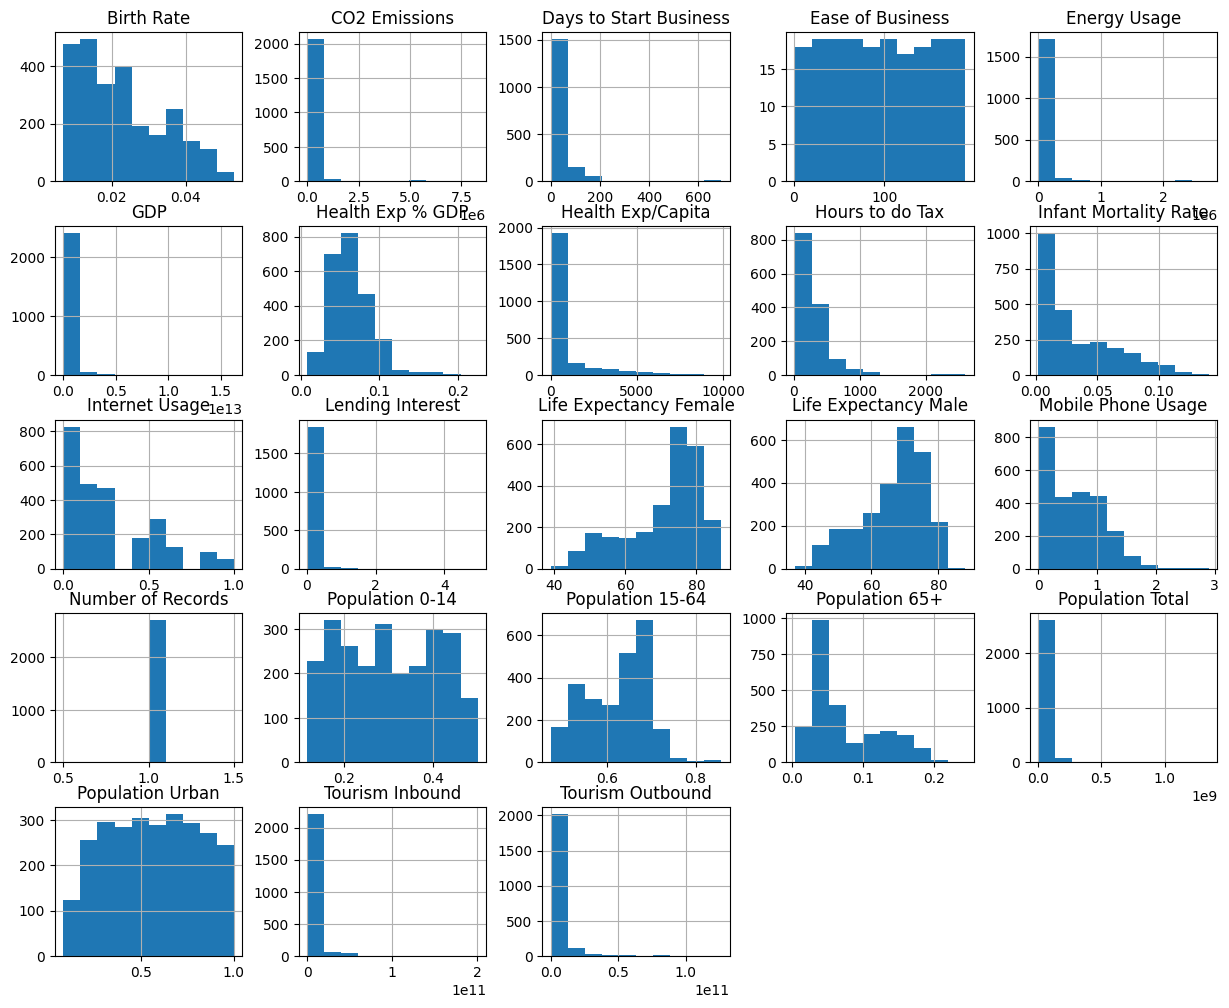

In [ ]:
#Univariate Analysis
#Histogram
df_model.hist(figsize=(15,12))
plt.show()


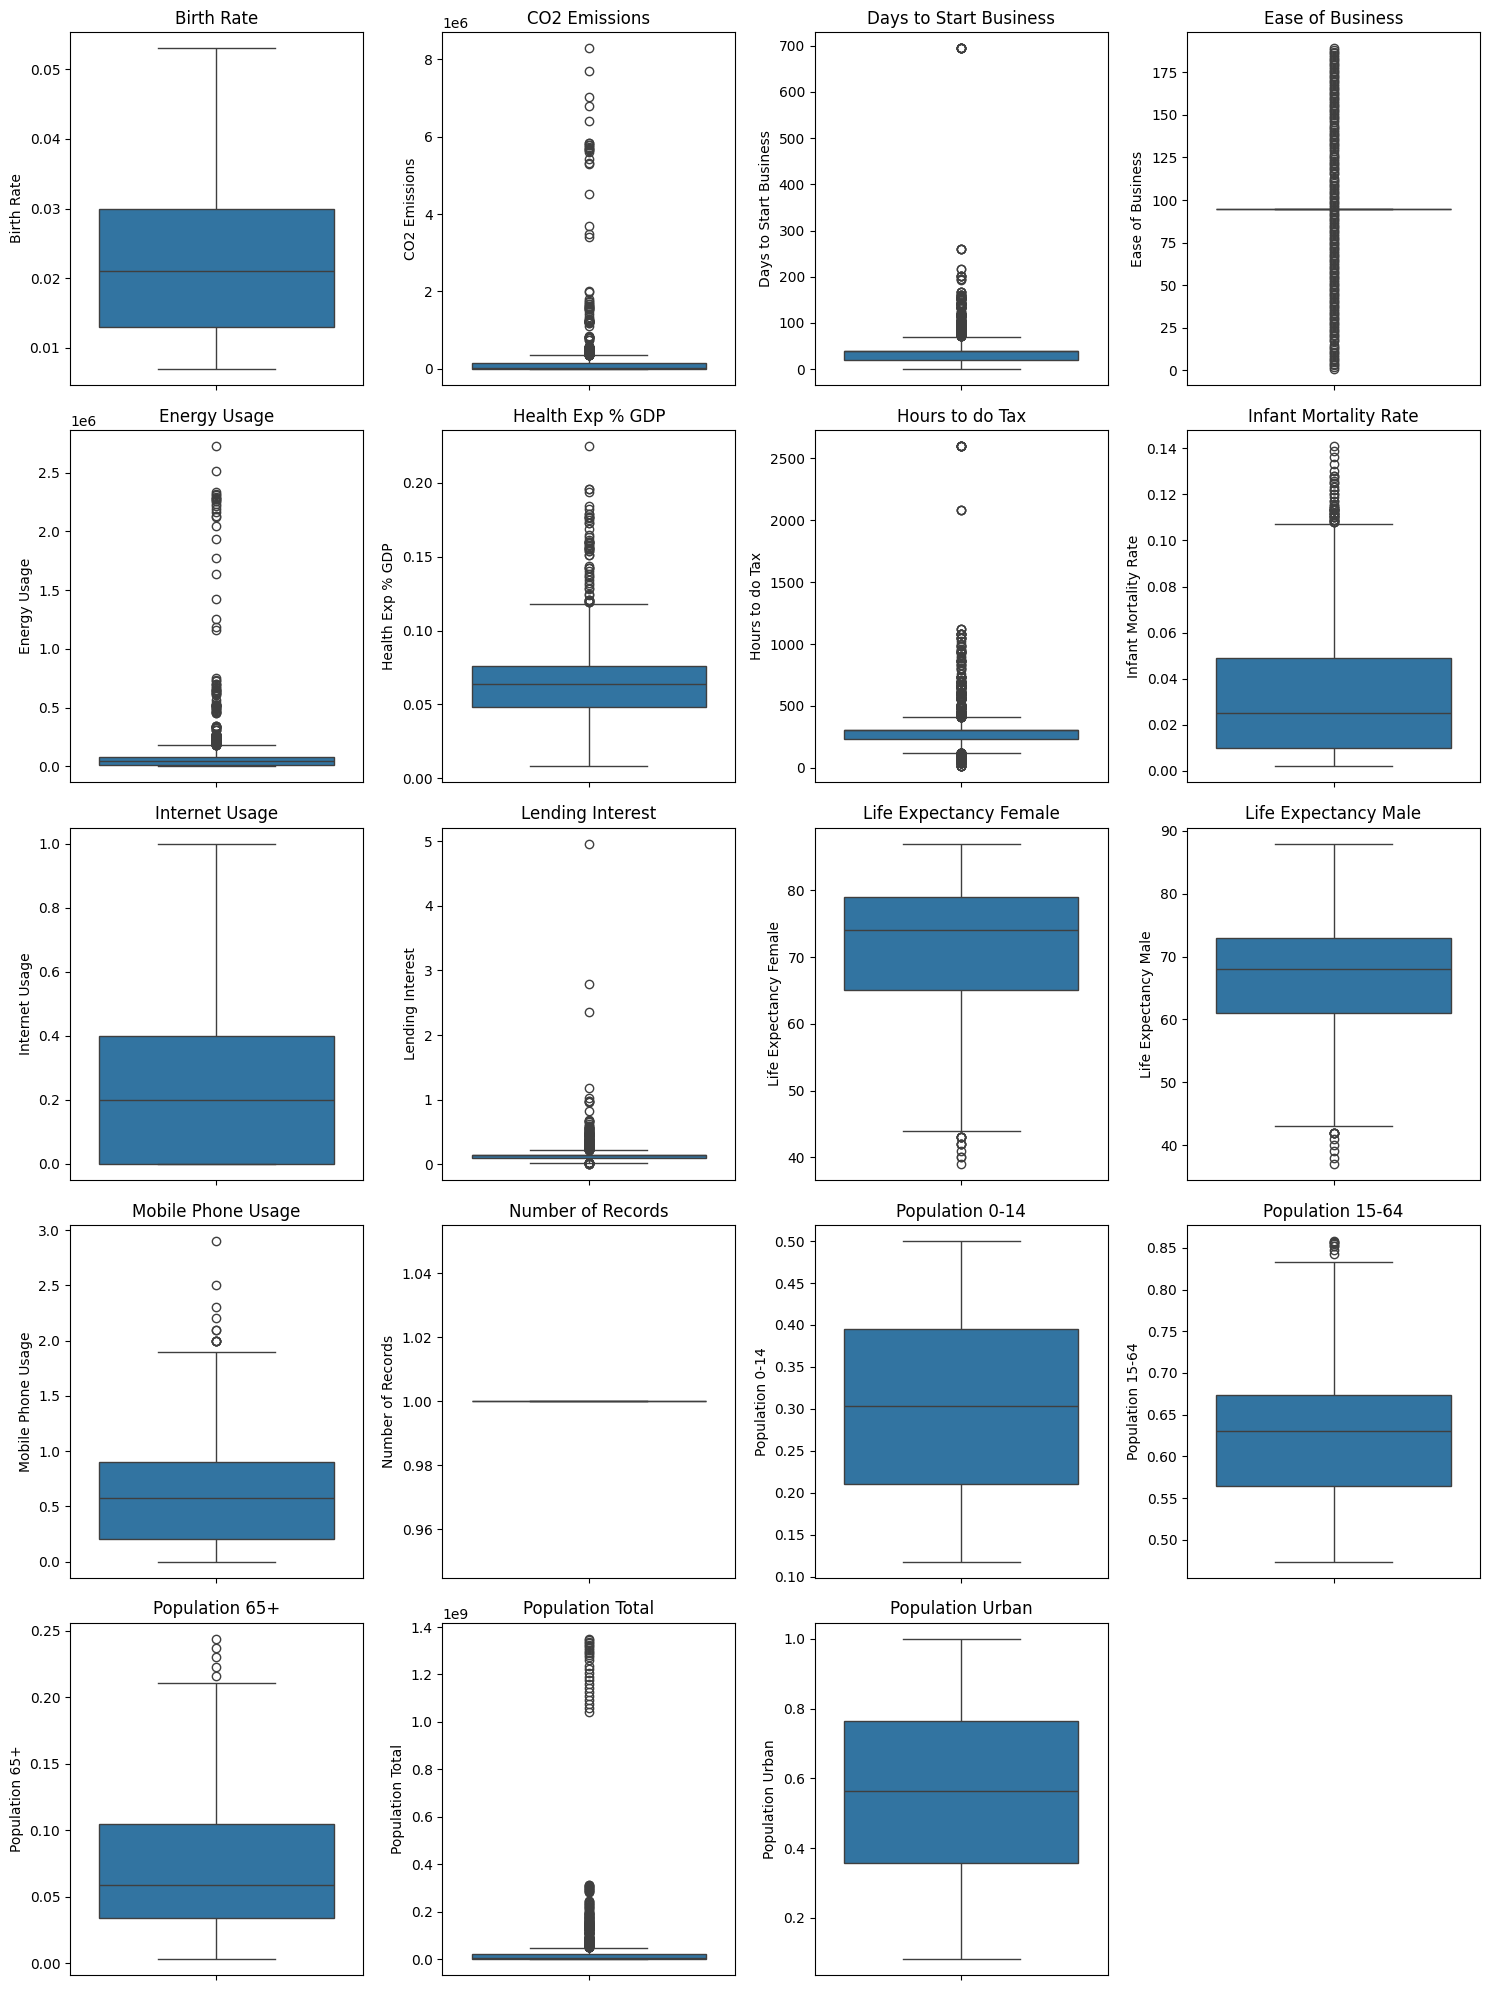

In [ ]:
 #outlier Detection (Boxplots)
import math

cols = 4
rows = math.ceil(len(numerical_cols) / cols)

plt.figure(figsize=(15, rows * 4))

for i, col in enumerate(numerical_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


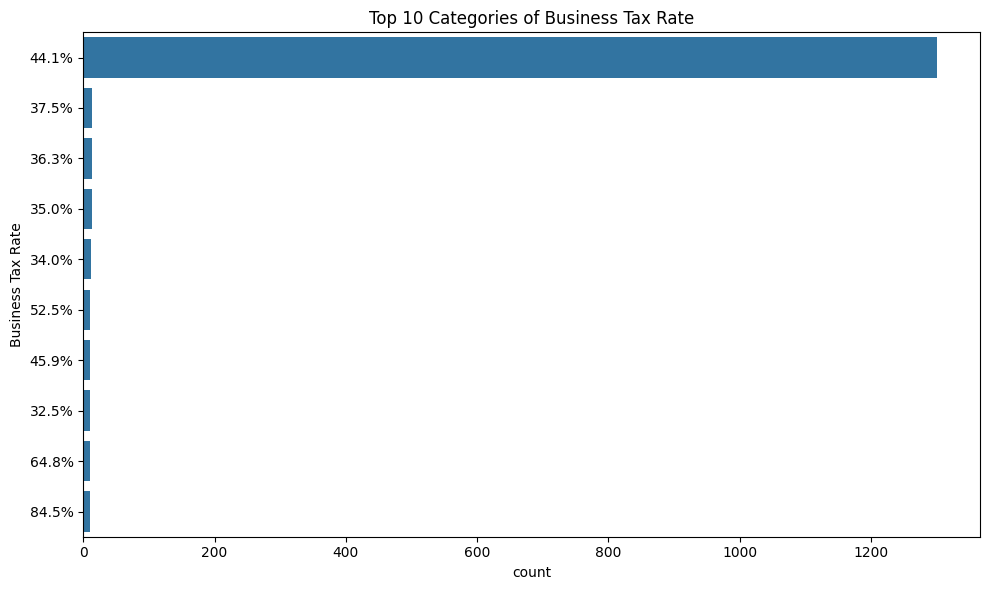

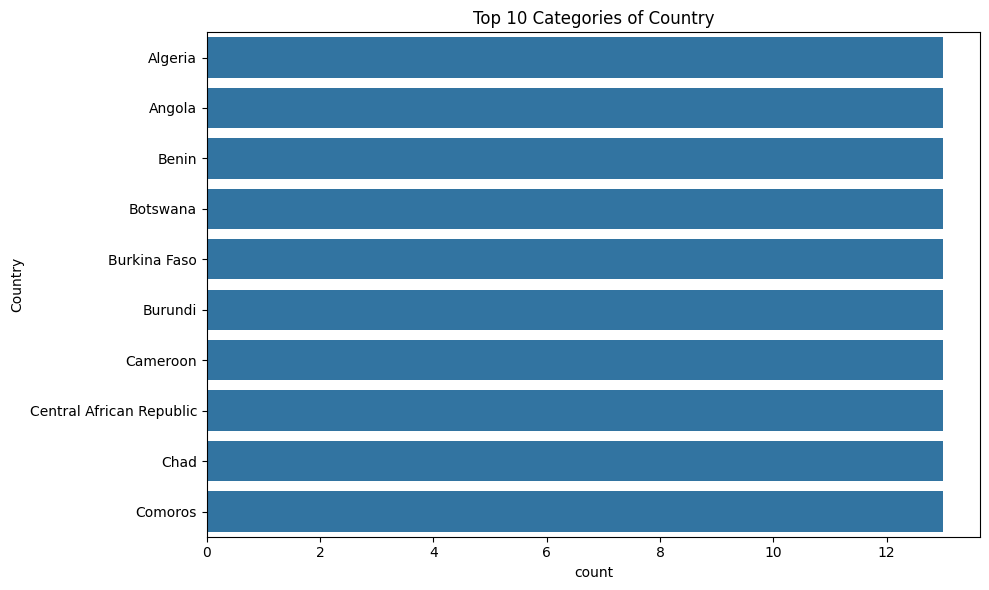

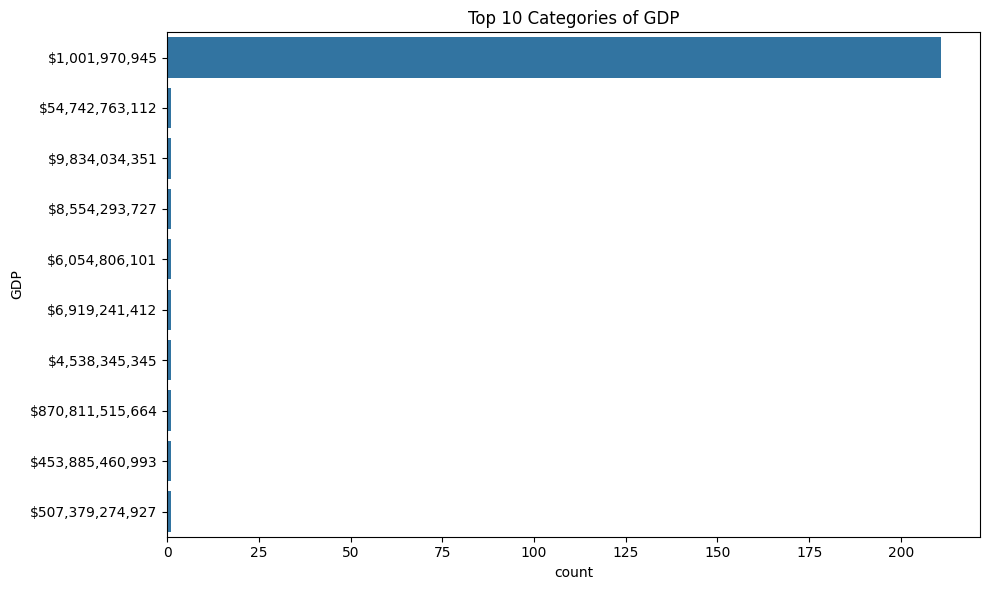

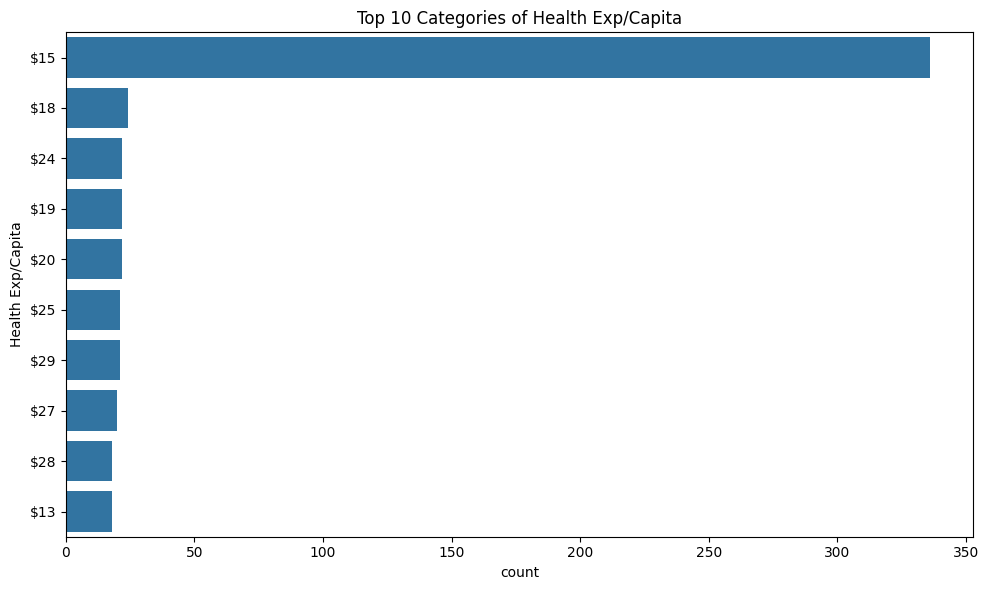

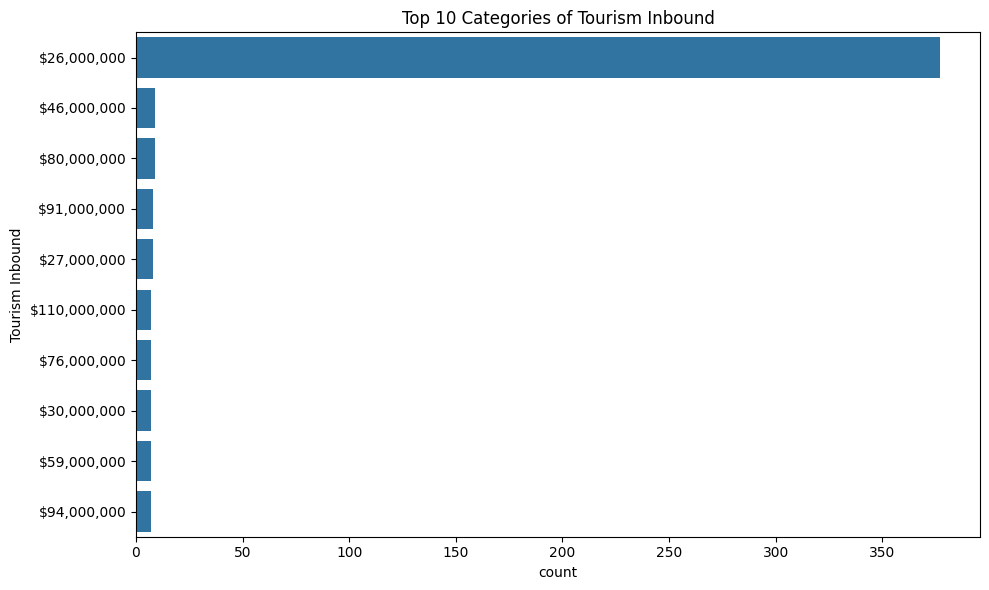

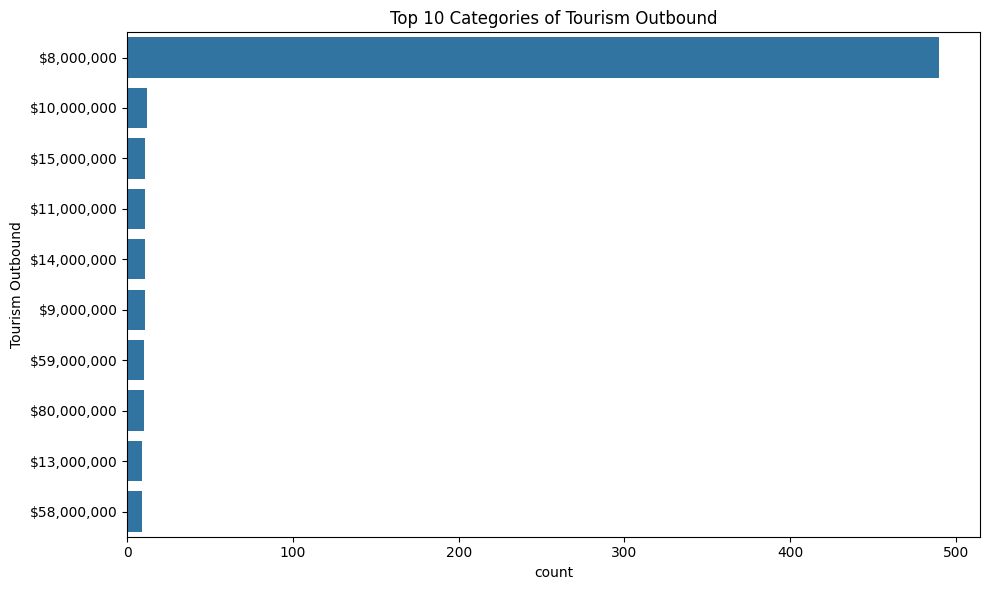

In [ ]:
# count plot
for col in categorical_cols:
    plt.figure(figsize=(10,6))
    top = df[col].value_counts().nlargest(10).index
    sns.countplot(y=df[col], order=top)
    plt.title(f"Top 10 Categories of {col}")
    plt.tight_layout()
    plt.show()


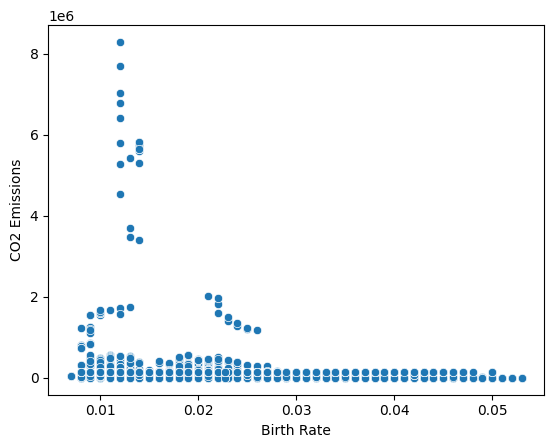

In [ ]:
# Bivariate Analysis
# Scatter Plot
sns.scatterplot(x=numerical_cols[0], y=numerical_cols[1], data=df)
plt.show()


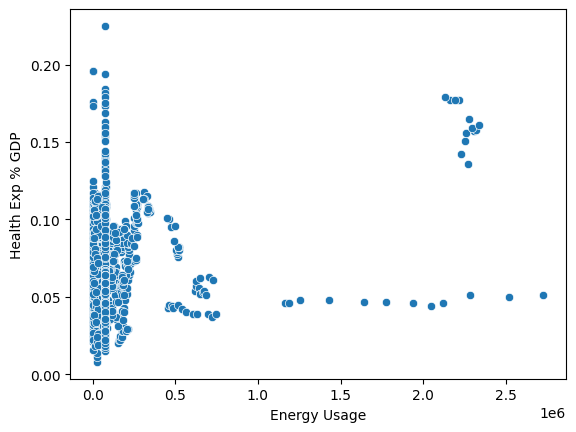

In [ ]:
# Scatter Plot
sns.scatterplot(x=numerical_cols[4], y=numerical_cols[5], data=df)
plt.show()


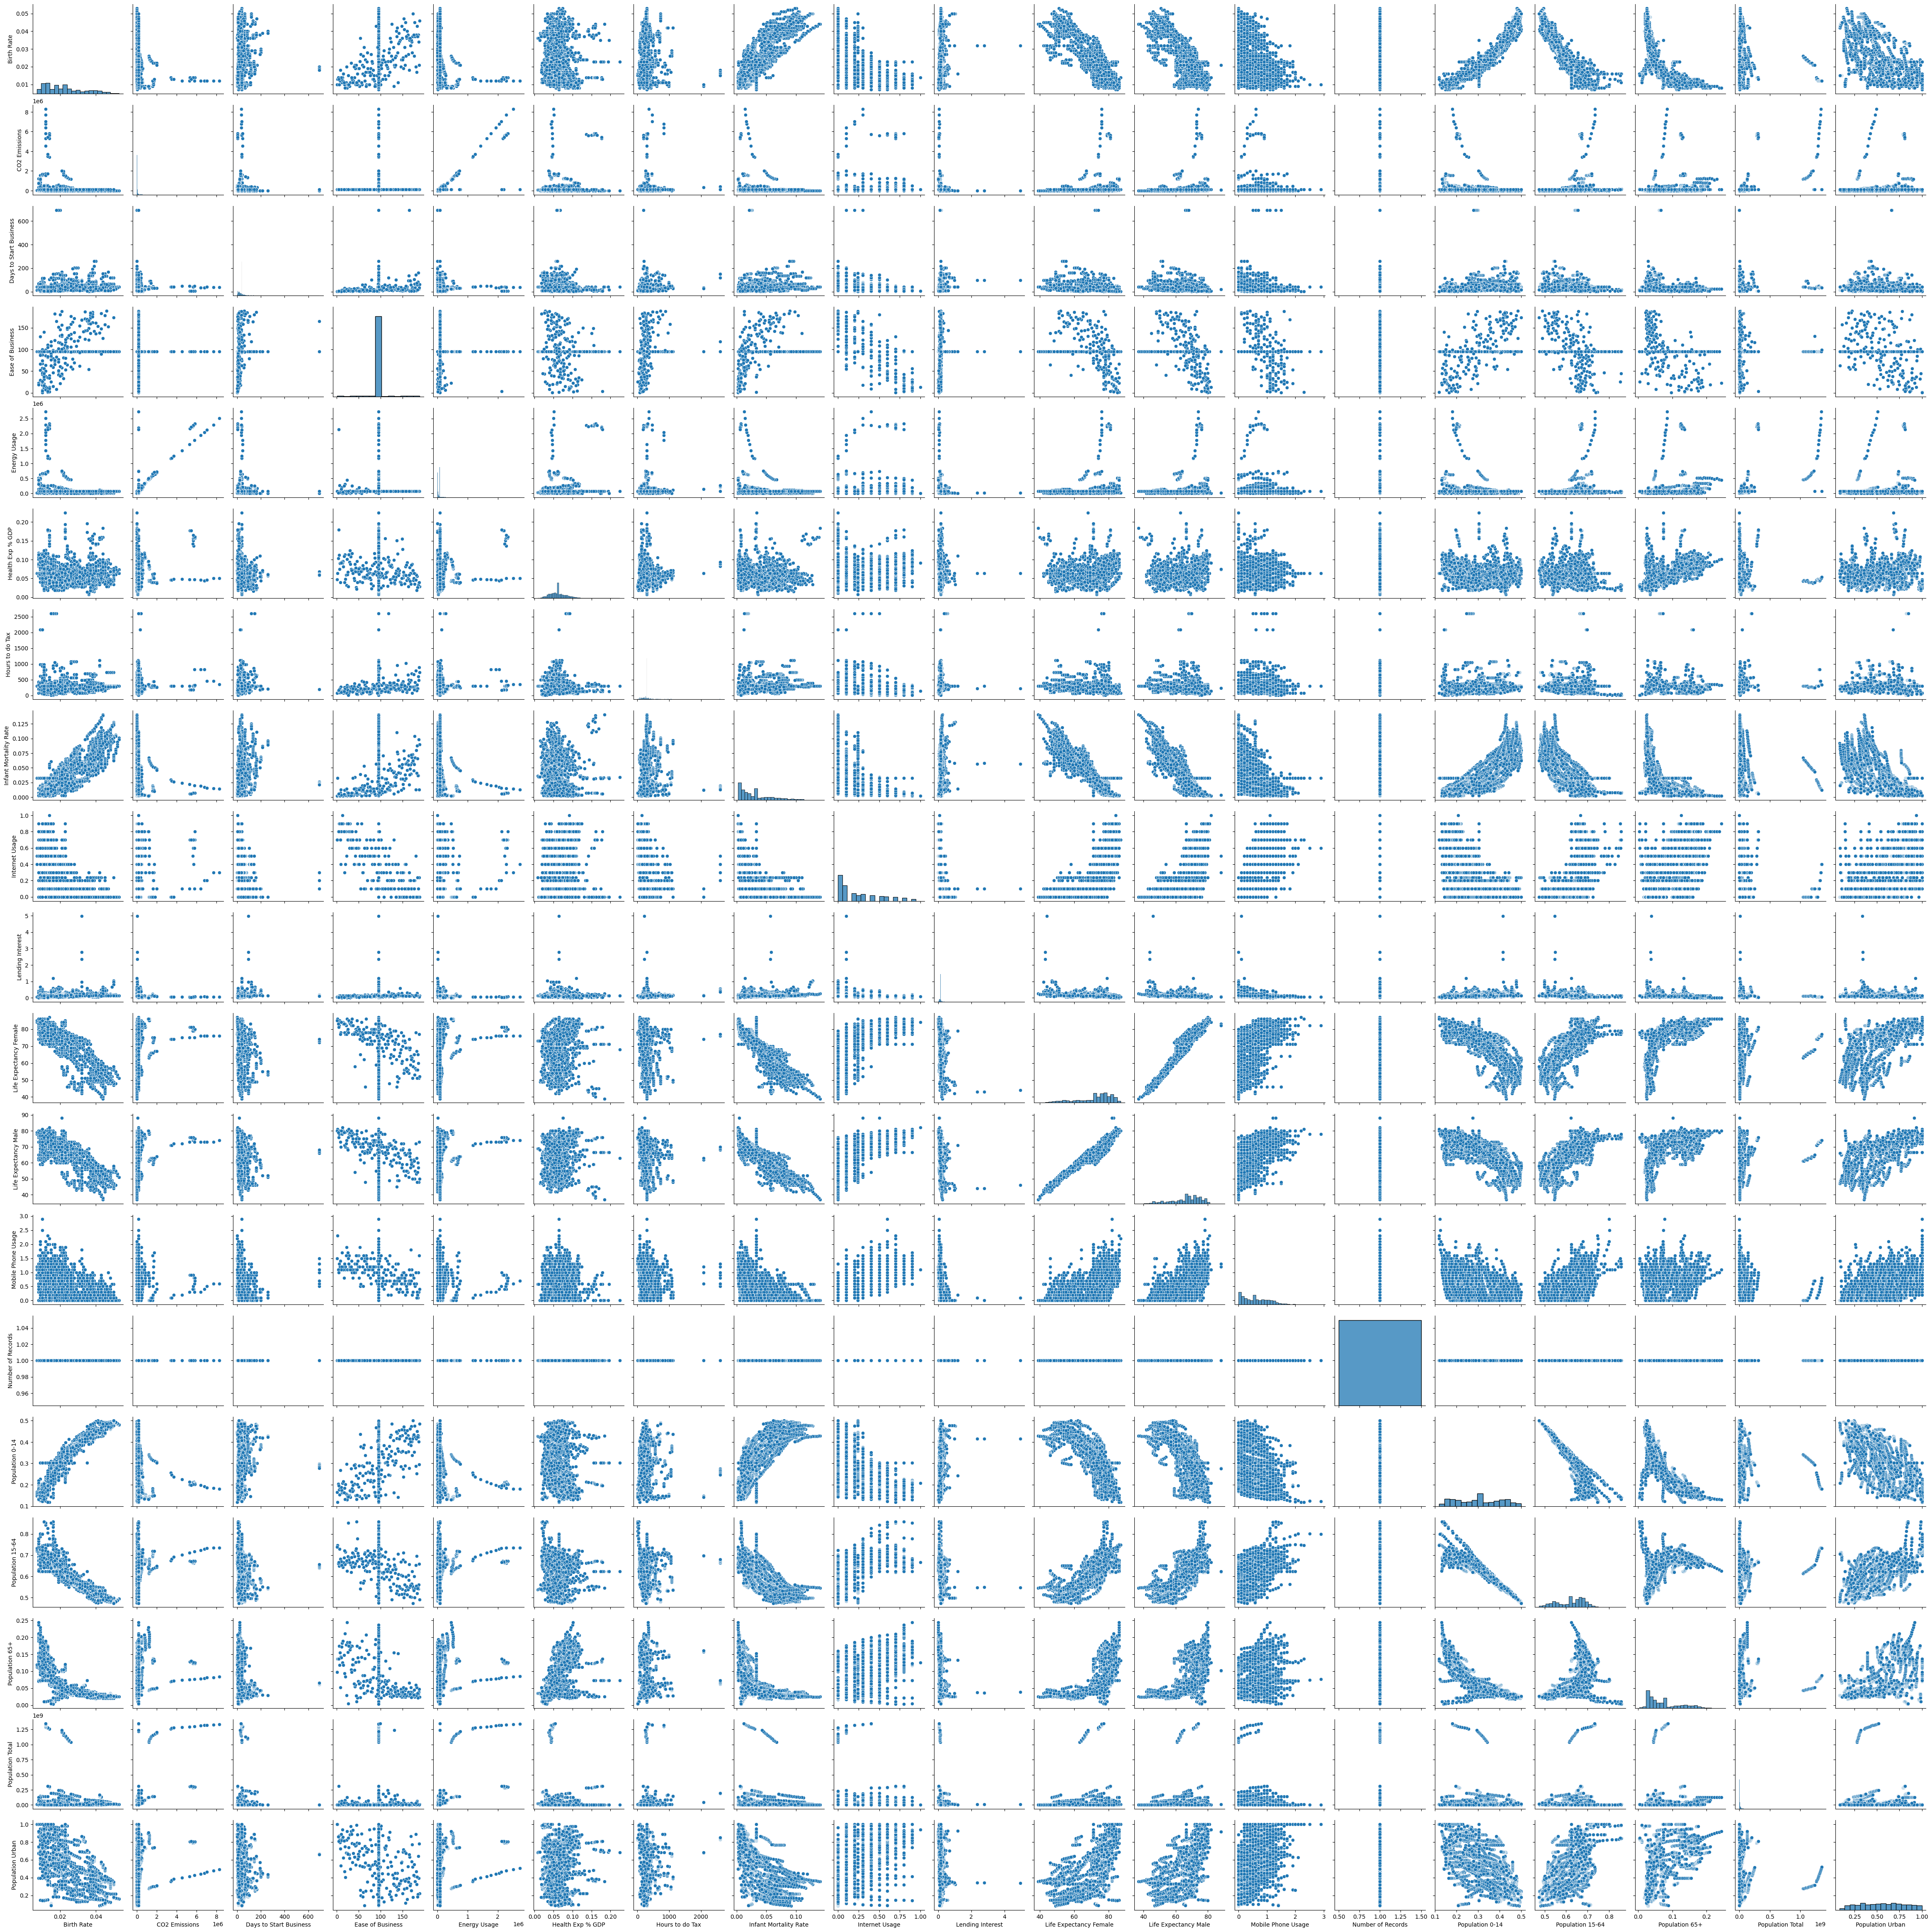

In [ ]:
#Pair Plot
sns.pairplot(df[numerical_cols])
plt.show()


In [ ]:
percent_cols = [
    col for col in df_model.columns
    if df_model[col].astype(str).str.contains('%').any()
]


In [ ]:
#Convert % Columns to Numeric
for col in percent_cols:
    df_model[col] = (
        df_model[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .replace('nan', np.nan)
        .astype(float)
        / 100
    )


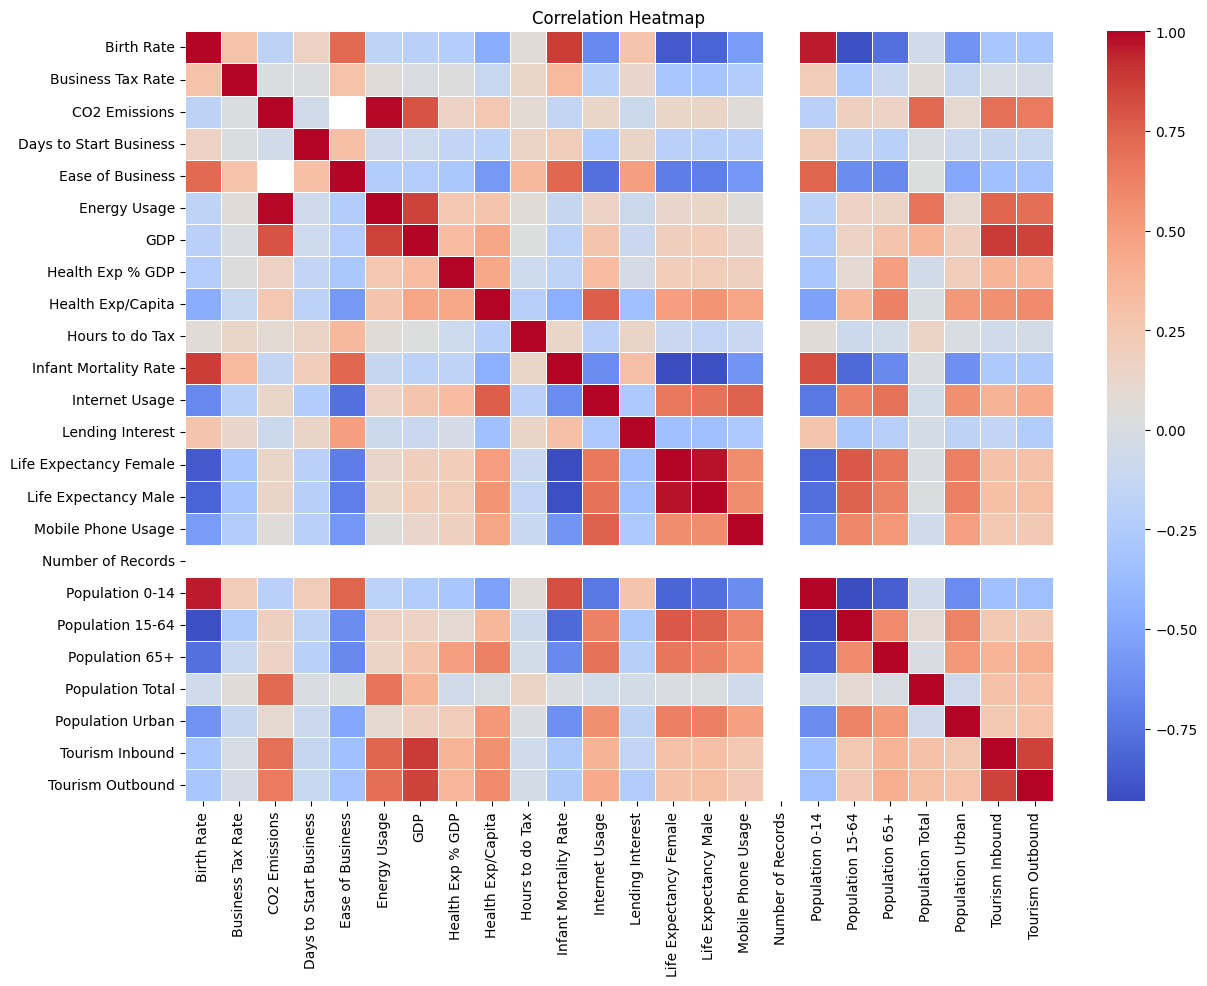

In [ ]:
#Correlation Analysis
plt.figure(figsize=(14,10))
sns.heatmap(df_model.corr(), cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


In [ ]:

# Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model)


In [ ]:
#MODEL BUILDING (CLUSTERING)


In [ ]:
df_num = df.select_dtypes(include='number')
df_num = df_num.fillna(df_num.mean())


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)


In [ ]:
#MODEL BUILDING (CLUSTERING)

In [ ]:
#Algorithm 1: K-Means Clustering


In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df_num["KMeans_Cluster"] = kmeans_labels


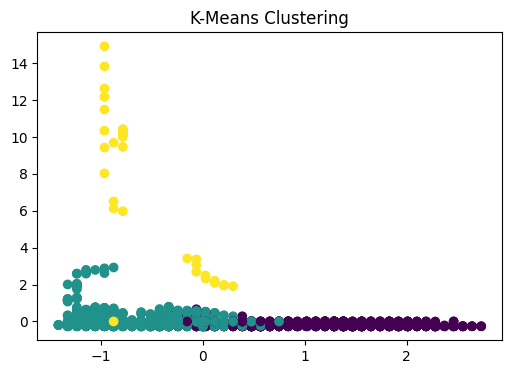

In [ ]:
# Visualization
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.show()


In [ ]:
# Algorithm 2: Hierarchical Clustering
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

hc_labels = hc.fit_predict(X_scaled)

df_num["Hierarchical_Cluster"] = hc_labels


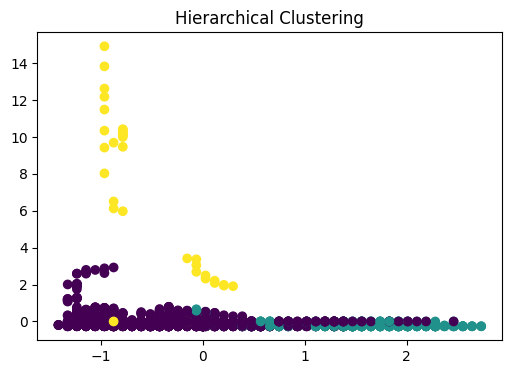

In [ ]:
#Visualization
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.show()


In [ ]:
# Algorithm 3: DBSCAN Clustering
from sklearn.cluster import DBSCAN

In [ ]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df_num["DBSCAN_Cluster"] = dbscan_labels


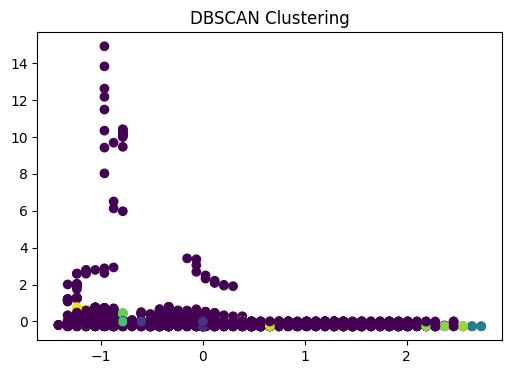

In [ ]:
# Visualization
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.show()


In [ ]:
# Install if not installed
# !pip install hdbscan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Apply Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# Silhouette Score
gmm_score = silhouette_score(X_scaled, gmm_labels)
print("GMM Silhouette Score:", gmm_score)

GMM Silhouette Score: 0.3252432765479828


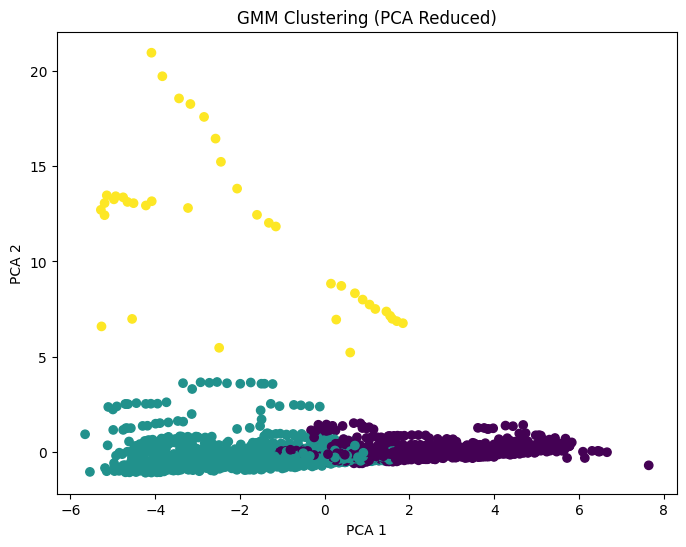

In [ ]:
# PCA Reduction
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=gmm_labels, cmap='viridis')
plt.title("GMM Clustering (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


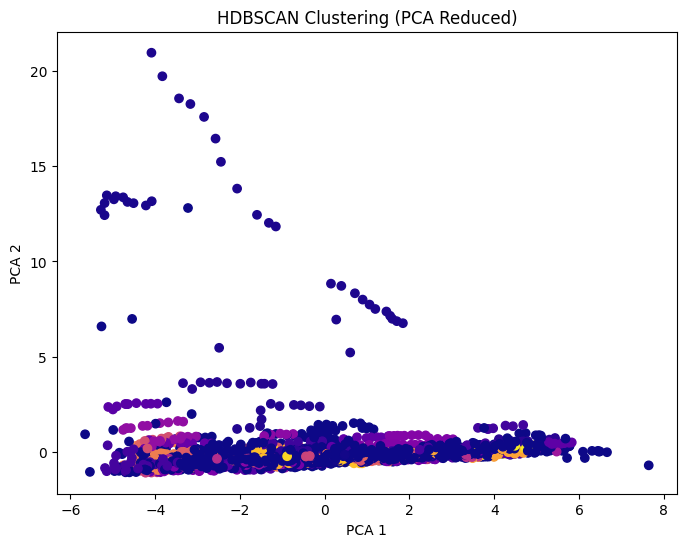

In [ ]:
# 1️⃣ PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2️⃣ HDBSCAN
import hdbscan
hdb = hdbscan.HDBSCAN(min_cluster_size=5)
hdb_labels = hdb.fit_predict(X_scaled)

# 3️⃣ Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=hdb_labels, cmap='plasma')
plt.title("HDBSCAN Clustering (PCA Reduced)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [ ]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
hc_score = silhouette_score(X_scaled, hc_labels)
gmm_score = silhouette_score(X_scaled, gmm_labels)

# Important: HDBSCAN may contain noise (-1 labels)
hdb_score = silhouette_score(X_scaled[hdb_labels != -1],
                             hdb_labels[hdb_labels != -1])
print("KMeans Score:", kmeans_score)
print("Hierarchical Score:", hc_score)
print("GMM Score:", gmm_score)
print("HDBSCAN Score:", hdb_score)


KMeans Score: 0.34283057197358613
Hierarchical Score: 0.32670157770172287
GMM Score: 0.3252432765479828
HDBSCAN Score: 0.3832073844606253
